# 1. Overview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

In [ ]:
customers = pd.read_csv("D:/vinuni_datathon2026/vinuni_datathon2026/raw_datasets/customers.csv")
customers

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search
...,...,...,...,...,...,...,...
121925,157556,59936,Vung Tau,2016-03-03,Female,18-24,direct
121926,157557,59936,Vung Tau,2021-05-11,Female,45-54,social_media
121927,157558,59936,Vung Tau,2017-02-27,Female,25-34,referral
121928,157561,59937,Buon Ma Thuot,2018-10-15,Non-binary,45-54,paid_search


In [ ]:
customers.shape

(121930, 7)

In [ ]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   customer_id          121930 non-null  int64
 1   zip                  121930 non-null  int64
 2   city                 121930 non-null  str  
 3   signup_date          121930 non-null  str  
 4   gender               121930 non-null  str  
 5   age_group            121930 non-null  str  
 6   acquisition_channel  121930 non-null  str  
dtypes: int64(2), str(5)
memory usage: 11.1 MB


## Tổng Quan Dữ Liệu: `customers`

### 1. Mô Tả Bảng

Bảng **`customers`** lưu trữ thông tin hồ sơ của khách hàng, bao gồm định danh, địa lý, thời gian đăng ký và các thuộc tính nhân khẩu học. Đây là bảng trung tâm liên kết với các bảng giao dịch khác trong hệ thống.

---

### 2. Schema & Mô Tả Cột

| STT | Cột | Kiểu dữ liệu | Ràng buộc | Mô tả |
|-----|-----|-------------|-----------|-------|
| 0 | `customer_id` | `int64` | PK · NOT NULL | Khóa chính định danh khách hàng |
| 1 | `zip` | `int64` | FK → `geography.zip` · NOT NULL | Mã bưu chính |
| 2 | `city` | `str` | NOT NULL | Tên thành phố của khách hàng |
| 3 | `signup_date` | `str` (date) | NOT NULL | Ngày đăng ký tài khoản (YYYY-MM-DD) |
| 4 | `gender` | `str` | NOT NULL | Giới tính khách hàng |
| 5 | `age_group` | `str` | NOT NULL | Nhóm tuổi khách hàng |
| 6 | `acquisition_channel` | `str` | NOT NULL | Kênh tiếp thị mà khách hàng đăng ký qua |

---

### 3. Thống Kê Tổng Quan

| Chỉ số | Giá trị |
|--------|---------|
| Tổng số bản ghi | **121,930** |
| Tổng số cột | **7** |
| Cột kiểu số (`int64`) | 2 (`customer_id`, `zip`) |
| Cột kiểu chuỗi (`str`) | 5 (`city`, `signup_date`, `gender`, `age_group`, `acquisition_channel`) |
| Giá trị NULL | **0** — Dữ liệu hoàn chỉnh, không thiếu |
| Dung lượng bộ nhớ | ~11.1 MB |

---

### 4. Lưu Ý Tiền Xử Lý

- Cột `signup_date` đang ở kiểu `str` → cần chuyển sang `datetime` trước khi phân tích thời gian.
- Cột `zip` là khóa ngoại liên kết với bảng `geography` → cần kiểm tra tính toàn vẹn tham chiếu.
- Các cột phân loại (`gender`, `age_group`, `acquisition_channel`) nên được kiểm tra phân phối giá trị và encoding trước khi đưa vào model.


# 2. Check quality and preprocessing

In [ ]:
# Chuyển signup_date → datetime
customers['signup_date'] = pd.to_datetime(customers['signup_date'], format='%Y-%m-%d', errors='coerce')

In [ ]:
# Kiếm tra khóa chính
customers["customer_id"].duplicated().sum()

np.int64(0)

In [ ]:
# Kiểm tra toàn vẹn tham chiếu với geography
geography = pd.read_csv('D:/vinuni_datathon2026/vinuni_datathon2026/raw_datasets/geography.csv')

zip_geo = set(geography['zip'].unique())
zip_cust = set(customers['zip'].unique())

orphan_zips = zip_cust - zip_geo          # zip trong customers nhưng không có trong geography
missing_geo = zip_geo - zip_cust          # zip trong geography nhưng không có customers nào

orphan_rows = customers[customers['zip'].isin(orphan_zips)]

print("=== Referential Integrity: customers.zip → geography.zip ===")
print(f"Distinct ZIP trong customers  : {len(zip_cust):,}")
print(f"Distinct ZIP trong geography  : {len(zip_geo):,}")
print(f"ZIP hợp lệ (có trong geography): {len(zip_cust & zip_geo):,}")
print(f"ZIP mồ côi (orphan) trong customers: {len(orphan_zips):,}")
print(f"  → Số dòng bị ảnh hưởng: {len(orphan_rows):,}")
print(f"ZIP trong geography không có customer: {len(missing_geo):,}")

if len(orphan_zips) > 0:
    print("\nOrphan ZIP codes:")
    print(sorted(orphan_zips))
else:
    print("\nToàn vẹn tham chiếu OK — Không có ZIP mồ côi.")


=== Referential Integrity: customers.zip → geography.zip ===
Distinct ZIP trong customers  : 31,491
Distinct ZIP trong geography  : 39,948
ZIP hợp lệ (có trong geography): 31,491
ZIP mồ côi (orphan) trong customers: 0
  → Số dòng bị ảnh hưởng: 0
ZIP trong geography không có customer: 8,457

Toàn vẹn tham chiếu OK — Không có ZIP mồ côi.


In [ ]:
cols = ["city", "gender", "age_group", "acquisition_channel"]

for col in cols:
    vc = customers[col].value_counts(dropna=False)
    pct = (vc / len(customers) * 100).round(2)
    summary = pd.DataFrame({"count": vc, "pct (%)": pct})

    print(f"{'─'*50}")
    print(f"Cột: `{col}`  |  Distinct: {customers[col].nunique()}  |  Null: {customers[col].isna().sum()}")
    print(summary.to_string())
    print()


──────────────────────────────────────────────────
Cột: `city`  |  Distinct: 42  |  Null: 0
                     count  pct (%)
city                               
Cam Pha               4398     3.61
Thai Nguyen           4347     3.57
Phu Ly                4243     3.48
Hanoi                 4240     3.48
Ha Long               4236     3.47
Bac Ninh              4172     3.42
Hai Phong             4170     3.42
Nam Dinh              4169     3.42
Bac Giang             4160     3.41
Ninh Binh             4081     3.35
Son Tay               4075     3.34
Viet Tri              4054     3.32
Uong Bi               4026     3.30
Dong Hoi              3912     3.21
Kon Tum               3838     3.15
Lao Cai               3807     3.12
Hoi An                3760     3.08
Phan Thiet            3749     3.07
Phan Rang-Thap Cham   3734     3.06
Hue                   3719     3.05
Tuy Hoa               3674     3.01
Quang Ngai            3616     2.97
Da Nang               3616     2.97
Tam Ky  

In [ ]:
out_path = 'D:/vinuni_datathon2026/vinuni_datathon2026/cleaned_datasets/customers_cleaned.csv'
customers.to_csv(out_path, index=False)
print(f"Đã lưu: {out_path}")

# 3. EDA

In [ ]:
customers

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search
...,...,...,...,...,...,...,...
121925,157556,59936,Vung Tau,2016-03-03,Female,18-24,direct
121926,157557,59936,Vung Tau,2021-05-11,Female,45-54,social_media
121927,157558,59936,Vung Tau,2017-02-27,Female,25-34,referral
121928,157561,59937,Buon Ma Thuot,2018-10-15,Non-binary,45-54,paid_search


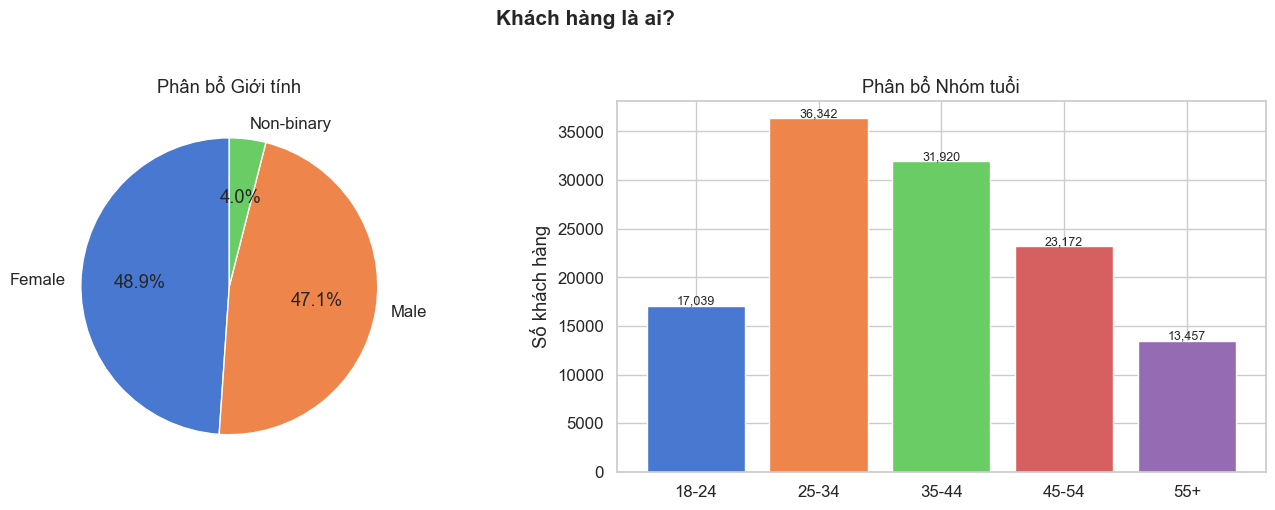

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
gender_vc = customers['gender'].value_counts()
axes[0].pie(gender_vc, labels=gender_vc.index, autopct='%1.1f%%',
            colors=sns.color_palette("muted"), startangle=90)
axes[0].set_title("Phân bổ Giới tính")

# Age Group
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
age_vc = customers['age_group'].value_counts().reindex(age_order)
axes[1].bar(age_vc.index, age_vc.values, color=sns.color_palette("muted", len(age_order)))
axes[1].set_title("Phân bổ Nhóm tuổi")
axes[1].set_ylabel("Số khách hàng")
for i, v in enumerate(age_vc.values):
    axes[1].text(i, v + 200, f"{v:,}", ha='center', fontsize=9)

plt.suptitle("Khách hàng là ai?", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


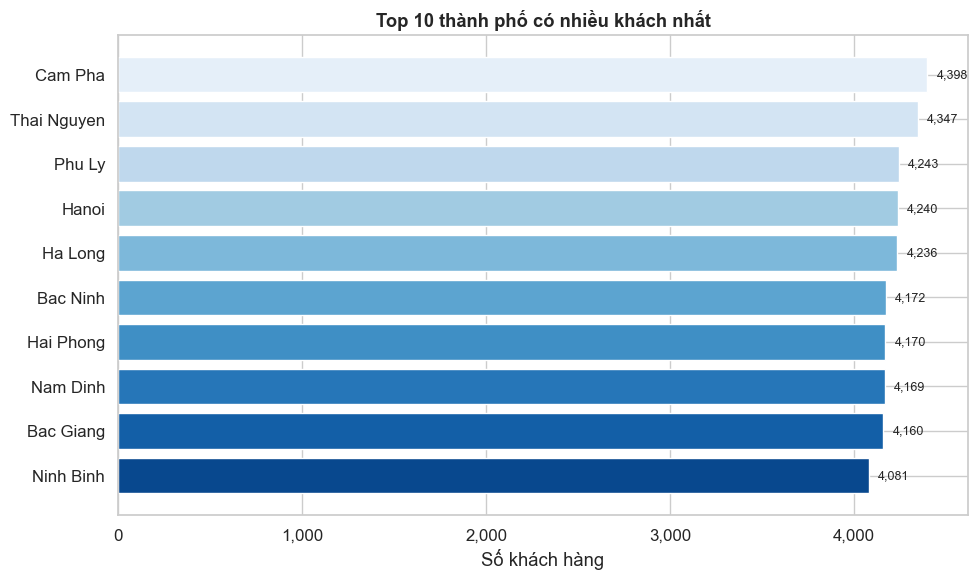

In [ ]:
city_vc = customers['city'].value_counts()
N = 10

fig, ax = plt.subplots(figsize=(10, 6))

top_cities = city_vc.head(N)
colors = sns.color_palette("Blues_r", N)

ax.barh(top_cities.index[::-1], top_cities.values[::-1], color=colors)
ax.set_title(f"Top {N} thành phố có nhiều khách nhất", fontweight='bold')
ax.set_xlabel("Số khách hàng")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for i, (city, v) in enumerate(zip(top_cities.index[::-1], top_cities.values[::-1])):
    ax.text(v + 50, i, f"{v:,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()


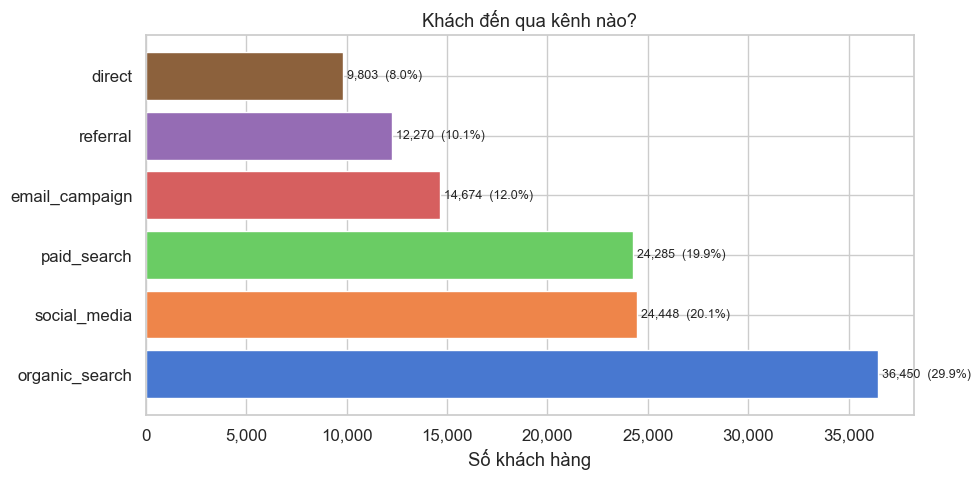

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ch_vc = customers['acquisition_channel'].value_counts()
bars = ax.barh(ch_vc.index, ch_vc.values, color=sns.color_palette("muted", len(ch_vc)))
ax.set_title("Khách đến qua kênh nào?")
ax.set_xlabel("Số khách hàng")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, v in zip(bars, ch_vc.values):
    ax.text(v + 200, bar.get_y() + bar.get_height()/2,
            f"{v:,}  ({v/len(customers)*100:.1f}%)", va='center', fontsize=9)

plt.tight_layout()
plt.show()


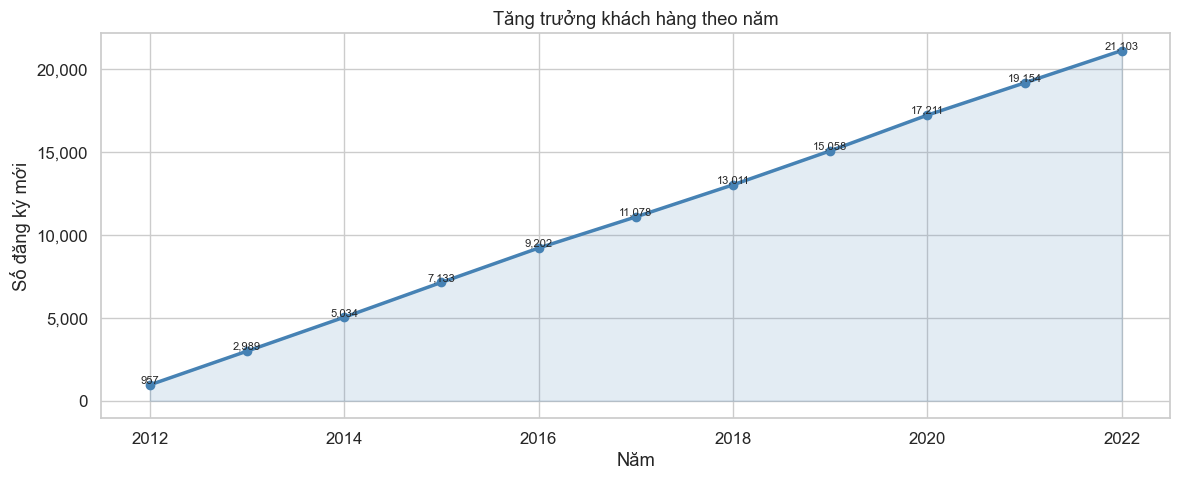

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

yearly = customers.groupby(customers['signup_date'].dt.year).size()
ax.plot(yearly.index, yearly.values, marker='o', linewidth=2.5, color='steelblue')
ax.fill_between(yearly.index, yearly.values, alpha=0.15, color='steelblue')
ax.set_title("Tăng trưởng khách hàng theo năm")
ax.set_xlabel("Năm")
ax.set_ylabel("Số đăng ký mới")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for x, y in zip(yearly.index, yearly.values):
    ax.text(x, y + 100, f"{y:,}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()


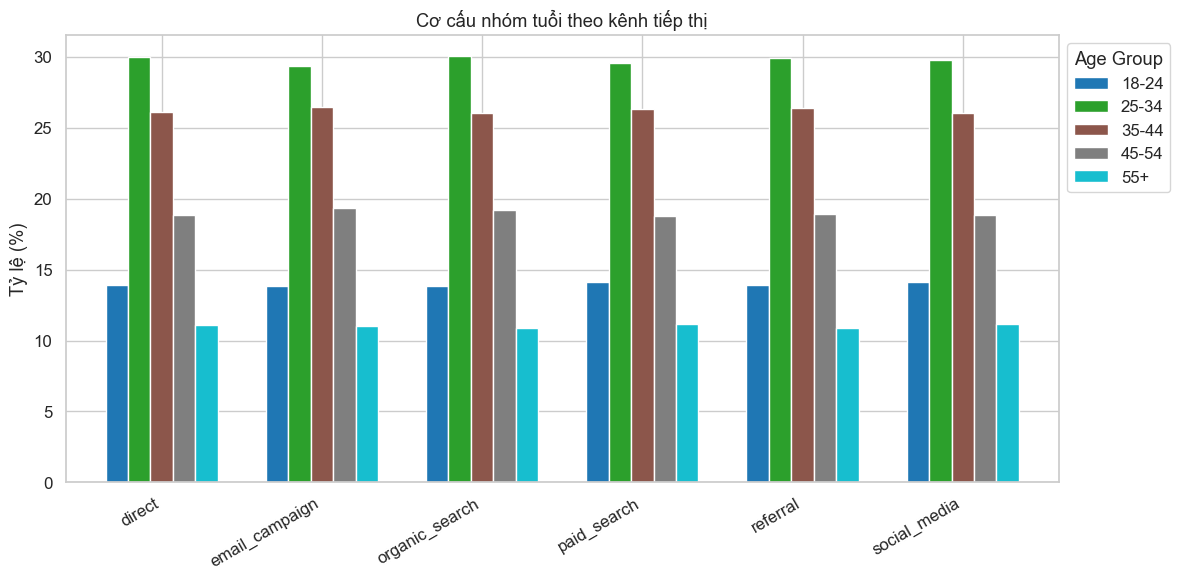

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

cross = pd.crosstab(customers['acquisition_channel'], customers['age_group'])
cross = cross[['18-24', '25-34', '35-44', '45-54', '55+']]
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

cross_pct.plot(kind='bar', ax=ax, colormap='tab10', width=0.7)
ax.set_title("Cơ cấu nhóm tuổi theo kênh tiếp thị")
ax.set_xlabel("")
ax.set_ylabel("Tỷ lệ (%)")
ax.legend(title="Age Group", bbox_to_anchor=(1, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


# Tiền Xử Lý & EDA Insights — `customers`

---

### 1. Tiền Xử Lý:

**Chuyển đổi `signup_date` sang `datetime`**

Cột `signup_date` ban đầu được lưu dưới dạng **chuỗi ký tự (`str`)** với định dạng `YYYY-MM-DD`. Để phục vụ phân tích chuỗi thời gian và trích xuất đặc trưng (năm, tháng, quý), cột này được chuyển sang kiểu `datetime64` bằng `pd.to_datetime()`.

| Trước xử lý | Sau xử lý |
|-------------|-----------|
| `dtype: object (str)` | `dtype: datetime64[ns]` |
| Không thể tính khoảng thời gian | Tính được tenure, cohort, tốc độ tăng trưởng |
| Không group theo năm/tháng | Hỗ trợ `.dt.year`, `.dt.month`, `.dt.quarter` |

> Kết quả: Không xuất hiện giá trị `NaT` sau khi parse — toàn bộ 121,930 bản ghi hợp lệ.  
> Khoảng thời gian: **2012 → 2022** (10 năm dữ liệu).

---

### 2. Insights từ EDA

#### Nhân khẩu học

- **Giới tính** phân bổ gần như **cân bằng hoàn toàn**: Female 48.9% — Male 47.1% — Non-binary 4.0%. Dữ liệu không bị thiên lệch giới tính, tạo điều kiện phân tích công bằng.
- **Nhóm tuổi 25–34 chiếm đông nhất** (36,342 khách — ~29.8%), tiếp theo là 35–44 (31,920). Hai nhóm này cộng lại chiếm hơn **56% tổng khách hàng** → đây là tệp khách hàng **lao động trẻ, thu nhập đang tăng**, có tiềm năng mua sắm cao.
- Nhóm **55+ chỉ chiếm 11%** (13,457 khách) — phân khúc cao tuổi còn nhiều dư địa khai thác.

#### Địa lý — Thành phố

- Top 10 thành phố có số khách **rất đồng đều**, dao động trong khoảng **4,081 – 4,398** — không có thành phố nào chiếm ưu thế tuyệt đối.
- **Cam Pha** dẫn đầu (4,398), bên cạnh các đô thị lớn như **Hà Nội** (4,240) và **Hải Phòng** (4,170). Điều này cho thấy nền tảng khách hàng **trải rộng địa lý**, không tập trung vào một trung tâm duy nhất.

#### Kênh tiếp thị

- **Organic Search** là kênh hiệu quả nhất với **36,450 khách (29.9%)** — phản ánh thương hiệu có **độ nhận diện tự nhiên tốt** hoặc đầu tư SEO hiệu quả.
- **Social Media** (20.1%) và **Paid Search** (19.9%) xếp thứ 2–3 sát nút, tổng cộng chiếm ~40% — cho thấy ngân sách marketing kỹ thuật số đang hoạt động song song hiệu quả.
- **Direct** chỉ chiếm 8% — tỷ lệ khách hàng trung thành truy cập trực tiếp còn thấp, có thể cải thiện qua loyalty program.

#### Tăng trưởng theo thời gian

- Số khách đăng ký mới tăng **tuyến tính bền vững** từ 957 (2012) lên **21,103 (2022)** — tốc độ tăng trưởng trung bình ~**+2,000 khách/năm**.
- Không có năm nào sụt giảm, cho thấy business **ổn định và có đà tăng trưởng dài hạn**.

#### Cross: Kênh × Nhóm tuổi

- Cơ cấu nhóm tuổi **đồng nhất hoàn toàn** qua tất cả các kênh tiếp thị (25–34 ~30%, 35–44 ~26%, 45–54 ~19%, 18–24 ~14%, 55+ ~11%).
- Điều này cho thấy **không có kênh nào đặc thù thu hút một nhóm tuổi riêng biệt** → chiến lược phân khúc theo kênh hiện tại chưa được cá nhân hoá theo độ tuổi. Đây là **cơ hội tối ưu hoá targeting**.
